<a href="https://colab.research.google.com/github/svvlozer0-cmd/Kaggle_Bilis_Performans_Takim_342/blob/main/YZTA_DATATHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**KÜTÜPHANELERİN YÜKLENMESİ**

In [ ]:
!pip install optuna catboost xgboost -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import optuna
from optuna.samplers import TPESampler
import warnings

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor, early_stopping
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set(style="whitegrid")
print("✅ Kütüphaneler yüklendi (LGBM, CatBoost, XGBoost).")

✅ Kütüphaneler yüklendi (LGBM, CatBoost, XGBoost).


**VERİLERİN OKUNMASI**

In [ ]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test_x.csv')

# ── SÜTUN KONTROLÜ ──────────────────────────────────────────
print("TRAIN SÜTUNLARI:", train.columns.tolist())
print("TEST SÜTUNLARI :", test.columns.tolist())
print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE :", test.shape)
# ────────────────────────────────────────────────────────────

TRAIN SÜTUNLARI: ['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']
TEST SÜTUNLARI : ['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']
TRAIN SHAPE: (56000, 24)
TEST SHAPE : (24000, 23)


**EDA - EKSİK VERİ ANALİZİ**


  Train EDA Raporu

📌 Eksik Veriler:
 meslek                   1378
vucut_kitle_indeksi      1752
uyku_oncesi_kafein_mg    1463
stres_skoru              1715
kronotip                 1968
ruh_sagligi_durumu       1096
dtype: int64


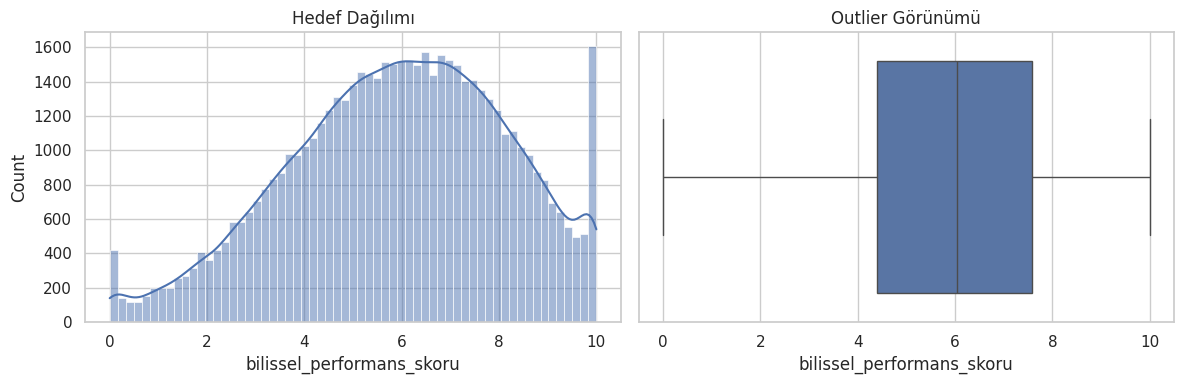

In [ ]:
def eda_full(df, label="Train"):
    print(f"\n{'='*40}\n  {label} EDA Raporu\n{'='*40}")
    null_report = df.isnull().sum()
    null_report = null_report[null_report > 0]
    print("\n📌 Eksik Veriler:\n", null_report) if len(null_report) else print("\n✅ Eksik veri yok.")
    if 'bilissel_performans_skoru' in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(df['bilissel_performans_skoru'], kde=True, ax=axes[0])
        axes[0].set_title("Hedef Dağılımı")
        sns.boxplot(x=df['bilissel_performans_skoru'], ax=axes[1])
        axes[1].set_title("Outlier Görünümü")
        plt.tight_layout(); plt.show()

eda_full(train, "Train")

**AKILLI VERİ TEMİZLEME (SMART IMPUTER)**

In [ ]:
def smart_imputer(df):
    df_c = df.copy()
    for col in df_c.select_dtypes(include=['object']).columns:
        df_c[col] = df_c[col].fillna("Bilinmiyor")
    for col in df_c.select_dtypes(include=['float64','int64']).columns:
        if col in ['id','bilissel_performans_skoru']: continue
        fill = df_c[col].median() if abs(df_c[col].skew()) > 1 else df_c[col].mean()
        df_c[col] = df_c[col].fillna(fill)
    return df_c

train_clean = smart_imputer(train)
test_clean  = smart_imputer(test)
print("✅ Eksik veriler temizlendi.")

✅ Eksik veriler temizlendi.


**OUTLIER**

In [ ]:
def clip_outliers(df, cols, factor=3.0):
    df_c = df.copy()
    for col in cols:
        Q1, Q3 = df_c[col].quantile(0.25), df_c[col].quantile(0.75)
        df_c[col] = df_c[col].clip(Q1 - factor*(Q3-Q1), Q3 + factor*(Q3-Q1))
    return df_c

num_features = [c for c in train_clean.select_dtypes(include=['float64','int64']).columns
                if c not in ['id','bilissel_performans_skoru']]
train_clean = clip_outliers(train_clean, num_features)
test_clean  = clip_outliers(test_clean,  num_features)
print("✅ Outlier'lar kısaltıldı.")

✅ Outlier'lar kısaltıldı.


**FEATURE ENGINEERING**

In [ ]:
def feature_engineering(df):
    d = df.copy()

    # Kategorik → Sayısal
    ruh_map = {'Saglikli':3,'Anksiyete':2,'Depresyon':1,'Anksiyete ve depresyon':0,'Bilinmiyor':1}
    d['ruh_sagligi_skoru']      = d['ruh_sagligi_durumu'].map(ruh_map).fillna(1)
    d['gun_tipi_numeric']       = d['gun_tipi'].map({'Hafta ici':0,'Hafta sonu':1})

    # Uyku
    d['toplam_kaliteli_uyku']   = d['rem_yuzdesi'] + d['derin_uyku_yuzdesi']
    d['sekerlemeli_uyku']       = d['toplam_kaliteli_uyku'] + (d['sekerleme_suresi_dk'] / 60)
    d['uyku_bozuklugu']         = d['uykuya_dalma_suresi_dk'] * d['gecelik_uyanma_sayisi']
    d['uyku_verimliligi']       = d['toplam_kaliteli_uyku'] / (d['gecelik_uyanma_sayisi'] + 1)

    # Stres
    d['stres_kare']             = d['stres_skoru'] ** 2
    d['stres_x_calisma']        = d['stres_skoru'] * d['gunluk_calisma_saati']
    d['stres_x_nabiz']          = d['stres_skoru'] * d['dinlenik_nabiz_bpm']
    d['stres_x_yas']            = d['stres_skoru'] * d['yas']
    d['ritim_bozuklugu_etkisi'] = d['hafta_sonu_uyku_farki_saat'] * d['stres_skoru']

    # Stres × Uyku Dengesi
    d['strese_karsi_uyku']      = d['toplam_kaliteli_uyku'] / (d['stres_skoru'] + 1)
    d['uyku_bozuklugu_x_stres'] = d['uyku_bozuklugu'] * d['stres_skoru']

    # Ruh Sağlığı
    d['uyku_x_ruh']             = d['toplam_kaliteli_uyku'] * d['ruh_sagligi_skoru']
    d['ruh_x_gun']              = d['ruh_sagligi_skoru'] * d['gun_tipi_numeric']

    # Fiziksel
    d['is_hareket_orani']       = d['gunluk_adim_sayisi'] / (d['gunluk_calisma_saati'] + 1)
    d['uyku_oncesi_kotu_skor']  = d['uyku_oncesi_kafein_mg'] * d['uyku_oncesi_ekran_suresi_dk']

    # Kategorik sütunları category tipine al
    for col in d.select_dtypes(include=['object']).columns:
        d[col] = d[col].astype('category')

    return d

train_fe = feature_engineering(train_clean)
test_fe  = feature_engineering(test_clean)
print(f"✅ FE tamamlandı. Toplam sütun: {train_fe.shape[1]}")

✅ FE tamamlandı. Toplam sütun: 41


**OPTUNA HİPERPARAMETRE OPTİMİZASYONU**

In [ ]:
X      = train_fe.drop(['id','bilissel_performans_skoru'], axis=1)
y      = train_fe['bilissel_performans_skoru']
X_test = test_fe.drop(['id'], axis=1)

# Kategorik sütun listesi — her model için ayrı format
cat_features = X.select_dtypes(include=['category']).columns.tolist()

# CatBoost için string formatında veri
X_cat      = X.copy()
X_test_cat = X_test.copy()
for col in cat_features:
    X_cat[col]      = X_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

# XGBoost için — category dtype ile tree_method=hist yeterli
X_xgb      = X.copy()
X_test_xgb = X_test.copy()


# ── 8. OPTUNA — LGBM HİPERPARAMETRE OPTİMİZASYONU ───────────
# Hızlı versiyon: %35 veri örneklemesi + 3 fold + 20 trial
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 4, 10),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 200),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective'         : 'regression',
        'metric'            : 'rmse',
        'random_state'      : 42,
        'verbose'           : -1,
    }

    # Hız için %35 örnekleme — parametrelerin yönünü bulmaya yeterli
    X_s = X.sample(frac=0.35, random_state=trial.number)
    y_s = y.loc[X_s.index]

    kf     = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in kf.split(X_s, y_s):
        m = LGBMRegressor(**params)
        m.fit(X_s.iloc[tr_idx], y_s.iloc[tr_idx],
              eval_set=[(X_s.iloc[val_idx], y_s.iloc[val_idx])],
              callbacks=[early_stopping(30, verbose=False)])
        preds = m.predict(X_s.iloc[val_idx])
        scores.append(np.sqrt(mean_squared_error(y_s.iloc[val_idx], preds)))
    return np.mean(scores)

print("\n🔍 Optuna optimizasyonu başlıyor (20 trial, ~5 dk)...")
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_params = study.best_params
best_params.update({'objective':'regression','metric':'rmse','random_state':42,'verbose':-1})
print(f"\n🏆 En iyi RMSE: {study.best_value:.5f}")
print(f"📋 En iyi parametreler:\n{best_params}")


🔍 Optuna optimizasyonu başlıyor (20 trial, ~5 dk)...


  0%|          | 0/20 [00:00<?, ?it/s]


🏆 En iyi RMSE: 1.22816
📋 En iyi parametreler:
{'n_estimators': 1317, 'learning_rate': 0.07913270952323785, 'max_depth': 4, 'num_leaves': 55, 'min_child_samples': 14, 'subsample': 0.6626651653816322, 'colsample_bytree': 0.6943386448447411, 'reg_alpha': 2.7678419414850017e-06, 'reg_lambda': 0.28749982347407854, 'objective': 'regression', 'metric': 'rmse', 'random_state': 42, 'verbose': -1}


**OPTUNA SONUÇ GÖRSELLEŞTİRME**

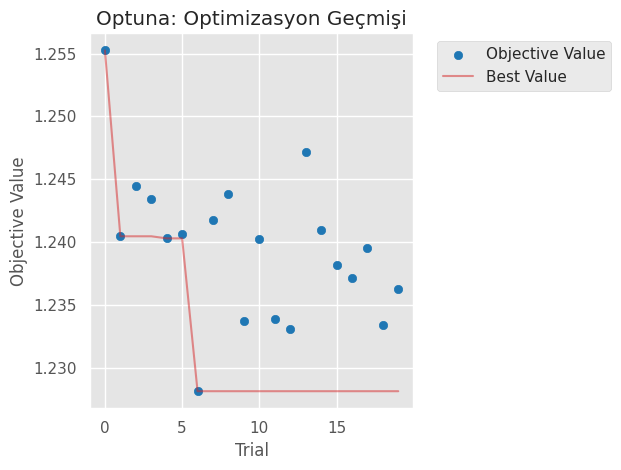

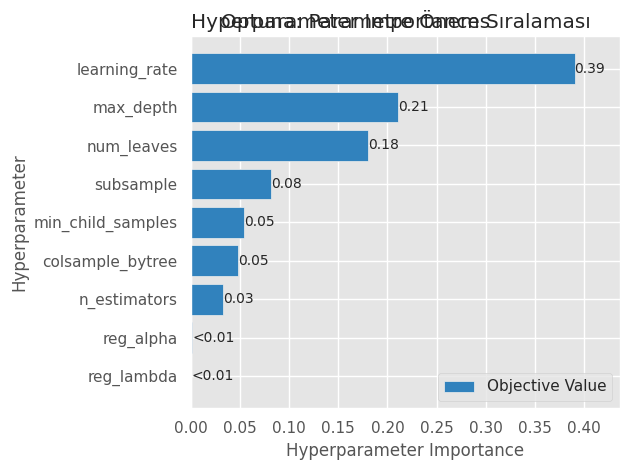

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna: Optimizasyon Geçmişi"); plt.tight_layout(); plt.show()
optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Optuna: Parametre Önem Sıralaması"); plt.tight_layout(); plt.show()

**CROSS-VALIDATION**

In [ ]:
# ── 10. ENSEMBLE CROSS-VALIDATION (LGBM + CAT + XGB) ───────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof   = {m: np.zeros(len(X))      for m in ['lgbm','cat','xgb']}
preds = {m: np.zeros(len(X_test)) for m in ['lgbm','cat','xgb']}

print("\n🚀 Ensemble CV Başlıyor (LGBM + CatBoost + XGBoost)...")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # ── LightGBM ────────────────────────────────────────
    m_lgbm = LGBMRegressor(**best_params)
    m_lgbm.fit(X.iloc[tr_idx], y_tr,
               eval_set=[(X.iloc[val_idx], y_val)],
               callbacks=[early_stopping(100, verbose=False)])
    oof['lgbm'][val_idx]  = m_lgbm.predict(X.iloc[val_idx])
    preds['lgbm']        += m_lgbm.predict(X_test) / 5

    # ── CatBoost (string kategorikler, early stopping) ──
    m_cat = CatBoostRegressor(
        iterations=2000, learning_rate=0.03, depth=7,
        loss_function='RMSE', random_seed=42, verbose=0,
        early_stopping_rounds=100
    )
    m_cat.fit(X_cat.iloc[tr_idx], y_tr,
              eval_set=(X_cat.iloc[val_idx], y_val),
              cat_features=cat_features)
    oof['cat'][val_idx]  = m_cat.predict(X_cat.iloc[val_idx])
    preds['cat']        += m_cat.predict(X_test_cat) / 5

    # ── XGBoost (early stopping, category desteği) ──────
    m_xgb = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=7,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        tree_method='hist', enable_categorical=True,
        early_stopping_rounds=100,
        eval_metric='rmse', random_state=42, verbosity=0
    )
    m_xgb.fit(X_xgb.iloc[tr_idx], y_tr,
              eval_set=[(X_xgb.iloc[val_idx], y_val)],
              verbose=False)
    oof['xgb'][val_idx]  = m_xgb.predict(X_xgb.iloc[val_idx])
    preds['xgb']        += m_xgb.predict(X_test_xgb) / 5

    print(f"  Fold {fold+1} ✅")


🚀 Ensemble CV Başlıyor (LGBM + CatBoost + XGBoost)...
  Fold 1 ✅
  Fold 2 ✅
  Fold 3 ✅
  Fold 4 ✅
  Fold 5 ✅


**OTOMATİK AĞIRLIK**

In [ ]:
rmse_scores = {m: np.sqrt(mean_squared_error(y, oof[m])) for m in oof}
inv_rmse    = {m: 1.0 / s for m, s in rmse_scores.items()}
total       = sum(inv_rmse.values())
weights     = {m: inv_rmse[m] / total for m in inv_rmse}

print("\n📊 MODEL SKORLARI (OOF RMSE):")
for m in rmse_scores:
    print(f"  {m.upper():5s}: RMSE={rmse_scores[m]:.5f}  |  Ağırlık=%{weights[m]*100:.1f}")

# Ensemble OOF RMSE
oof_ensemble = sum(oof[m] * weights[m] for m in oof)
ensemble_rmse = np.sqrt(mean_squared_error(y, oof_ensemble))
print(f"\n🏆 Ensemble OOF RMSE: {ensemble_rmse:.5f}")


📊 MODEL SKORLARI (OOF RMSE):
  LGBM : RMSE=1.22488  |  Ağırlık=%33.3
  CAT  : RMSE=1.21949  |  Ağırlık=%33.5
  XGB  : RMSE=1.22771  |  Ağırlık=%33.2

🏆 Ensemble OOF RMSE: 1.21992


**FEATURE IMPORTANCE**

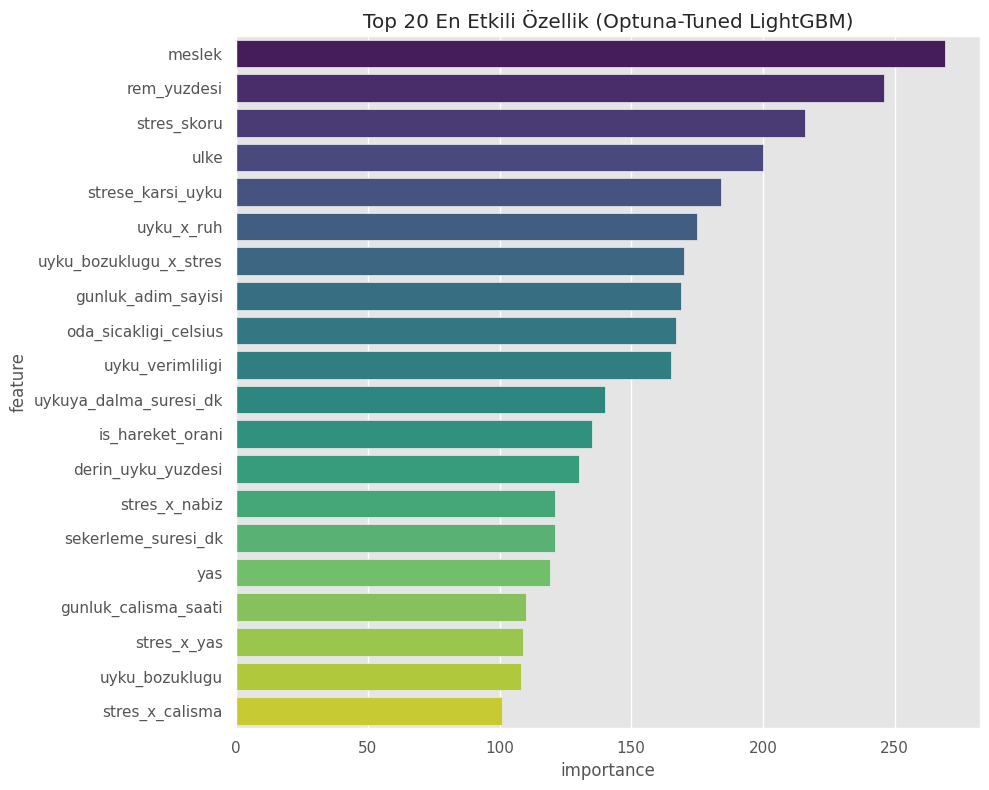

In [ ]:
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': m_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(20),
            palette='viridis')
plt.title('Top 20 En Etkili Özellik (Optuna-Tuned LightGBM)')
plt.tight_layout()
plt.show()

**SUBMISSION**

In [ ]:

final_test_preds = (preds['lgbm'] * weights['lgbm'] +
                    preds['cat'] * weights['cat'] +
                    preds['xgb'] * weights['xgb'])

final_test_preds = np.clip(final_test_preds, 0, 10)

submission = pd.DataFrame({
    'id': test_fe['id'],
    'bilissel_performans_skoru': final_test_preds
})

submission.to_csv('final_ensemble_v4.csv', index=False)
print("\n✅ final_ensemble_v4.csv oluşturuldu!")
print(submission['bilissel_performans_skoru'].describe())


✅ final_ensemble_v4.csv oluşturuldu!
count    24000.000000
mean         5.940334
std          1.857660
min          0.043778
25%          4.652028
50%          6.042266
75%          7.320298
max         10.000000
Name: bilissel_performans_skoru, dtype: float64
